In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import SVC
from sklearn import metrics
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from tdc.single_pred import ADME
from collections import defaultdict

In [11]:
from collections import defaultdict
from sklearn import metrics

list_data = ['CYP2D6_Veith', 'CYP3A4_Veith', 'CYP1A2_Veith', 'CYP2C9_Veith']

def create_dataset_morgan(df):
    fp_lst, y_clean = [], []
    for smiles, y_value in zip(df['Drug'], df['Y']):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fp_lst.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=512)))
            y_clean.append(y_value)
    return np.array(fp_lst), np.array(y_clean)


def create_dataset_maccs(df):
    fp_lst, y_clean = [], []
    for smiles, y_value in zip(df['Drug'], df['Y']):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fp_lst.append(np.array(AllChem.GetMACCSKeysFingerprint(mol)))
            y_clean.append(y_value)
    return np.array(fp_lst), np.array(y_clean)


def get_model(model_class):
    if model_class is XGBClassifier:
        return XGBClassifier(random_state=42, eval_metric='logloss')
    if model_class is SVC:
        return SVC(random_state=42, probability=True)
    if model_class is RandomForestClassifier:
        return RandomForestClassifier(random_state=42)
    if model_class is GaussianProcessClassifier:
        return GaussianProcessClassifier(random_state=42)
    raise ValueError(f"Unknown model: {model_class}")


def run_calc(dataset_names):
    # FIX 1: nested defaultdict so 3-level assignment works
    results_dict = defaultdict(lambda: defaultdict(dict))

    model_classes = [XGBClassifier, SVC, RandomForestClassifier, GaussianProcessClassifier]
    fp_funcs = {'morgan': create_dataset_morgan, 'maccs': create_dataset_maccs}

    for dataset in dataset_names:
        print(f"\n=== Dataset: {dataset} ===")
        data = ADME(name=dataset)
        split = data.get_split()

        train_data = split['train']
        test_data  = split['test']

        for fp_name, fp_func in fp_funcs.items():
            print(f"  Fingerprint: {fp_name}")
            train_x, train_y = fp_func(train_data)
            test_x,  test_y  = fp_func(test_data)

            for model_class in model_classes:
                name = model_class.__name__              # FIX 2: double underscores
                model = get_model(model_class)
                model.fit(train_x, train_y)

                y_pred = model.predict(test_x)

                # FIX 3: this block is now INSIDE the model loop
                results_dict[dataset][fp_name][name] = {
                    'accuracy':  metrics.accuracy_score(test_y, y_pred),
                    'roc-auc': metrics.roc_auc_score(test_y, y_pred),
                    'mcc': metrics.matthews_corrcoef(test_y, y_pred),
                }
                print(f"    {name:28s} done")

    return results_dict

In [12]:
# Step 1: run the training (this defines `results`)
results = run_calc(list_data)

# Step 2: build the comparison table
def build_long_table(results):
    rows = []
    for dataset, fps in results.items():
        for fp, models in fps.items():
            for model_name, scores in models.items():
                rows.append({
                    'dataset':     dataset,
                    'fingerprint': fp,
                    'model':       model_name,
                    **scores
                })
    return pd.DataFrame(rows).round(4)

long_table = build_long_table(results)
print(long_table)

Found local copy...
Loading...
Done!



=== Dataset: CYP2D6_Veith ===
  Fingerprint: morgan


[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerator
[14:04:31] DEPRECATION WARNING: please use MorganGenerat

    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done
    GaussianProcessClassifier    done
  Fingerprint: maccs
    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done


Found local copy...
Loading...
Done!


...

    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done
    GaussianProcessClassifier    done
  Fingerprint: maccs
    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done


Found local copy...
Loading...
Done!
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECAT

    GaussianProcessClassifier    done

=== Dataset: CYP2C9_Veith ===
  Fingerprint: morgan


[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerator
[14:11:05] DEPRECATION WARNING: please use MorganGenerat

    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done
    GaussianProcessClassifier    done
  Fingerprint: maccs
    XGBClassifier                done
    SVC                          done
    RandomForestClassifier       done
    GaussianProcessClassifier    done
         dataset fingerprint                      model  accuracy  roc-auc  \
0   CYP2D6_Veith      morgan              XGBClassifier    0.8633   0.6986   
1   CYP2D6_Veith      morgan                        SVC    0.8656   0.6628   
2   CYP2D6_Veith      morgan     RandomForestClassifier    0.8549   0.6247   
3   CYP2D6_Veith      morgan  GaussianProcessClassifier    0.8496   0.6894   
4   CYP2D6_Veith       maccs              XGBClassifier    0.8656   0.7237   
5   CYP2D6_Veith       maccs                        SVC    0.8595   0.6567   
6   CYP2D6_Veith       maccs     RandomForestClassifier    0.8614   0.6871   
7   CYP2D6_Veith       maccs  GaussianProcessClassi

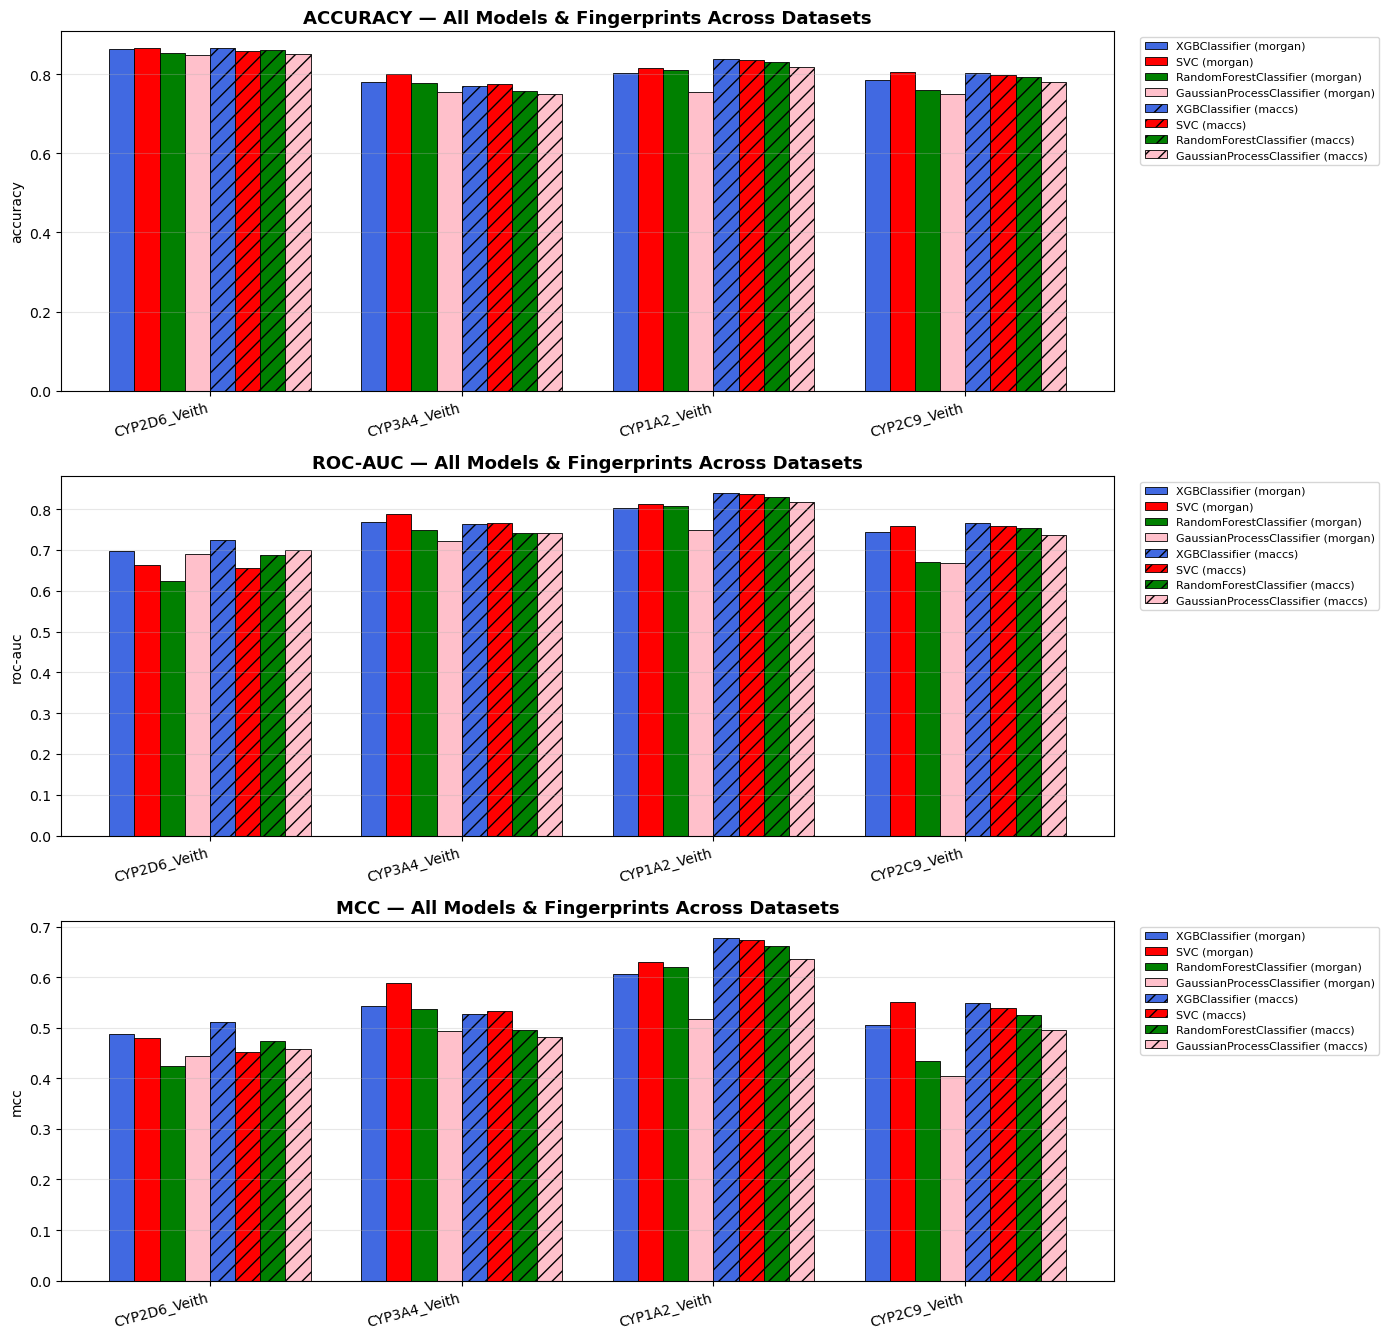

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(long_table, metrics_to_plot=('accuracy', 'roc-auc', 'mcc')):
    """
    One subplot per metric. Within each subplot:
      - X-axis: datasets
      - Grouped bars: one per (fingerprint, model) combo
    """
    datasets = long_table['dataset'].unique()
    models   = long_table['model'].unique()
    fps      = long_table['fingerprint'].unique()

    model_colors = dict(zip(models, ['royalblue', 'red', 'green', 'pink']))
    fp_hatches   = {'morgan': '', 'maccs': '//'}

    n_groups = len(datasets)
    n_bars   = len(models) * len(fps)
    bar_w    = 0.8 / n_bars
    x        = np.arange(n_groups)

    fig, axes = plt.subplots(len(metrics_to_plot), 1,
                             figsize=(14, 4.5 * len(metrics_to_plot)))
    if len(metrics_to_plot) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics_to_plot):
        i = 0
        for fp in fps:
            for model in models:
                values = []
                for ds in datasets:
                    row = long_table[(long_table['dataset'] == ds) &
                                     (long_table['fingerprint'] == fp) &
                                     (long_table['model'] == model)]
                    values.append(row[metric].values[0] if not row.empty else 0)

                ax.bar(x + i * bar_w, values, bar_w,
                       label=f'{model} ({fp})',
                       color=model_colors[model],
                       hatch=fp_hatches[fp],
                       edgecolor='black', linewidth=0.6)
                i += 1

        ax.set_title(f'{metric.upper()} — All Models & Fingerprints Across Datasets',
                     fontsize=13, fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xticks(x + bar_w * (n_bars - 1) / 2)
        ax.set_xticklabels(datasets, rotation=15, ha='right')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_model_comparison(long_table)